<a href="https://colab.research.google.com/github/aliabusohiban/Bike-Share-Demand-Feature-Engineering/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚲 Bike Share Demand — Feature Engineering

> **Goal:** Engineer new features to improve a model's ability to predict the total number  
> of bike-share rentals during a given hour of the day.

### Notebook Outline
| # | Section |
|---|---|
| 1 | Imports & Configuration |
| 2 | Helper Functions |
| 3 | Load & Inspect Data |
| 4 | Feature Engineering |
| 5 | Baseline Model (original features) |
| 6 | Engineered-Feature Model |
| 7 | Results Comparison |

---
## 1 · Imports & Configuration

In [1]:
# ── Standard library ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data & visualisation ───────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn — preprocessing ────────────────────────────────────────────────────
from sklearn import set_config
from sklearn.compose    import ColumnTransformer
from sklearn.pipeline   import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Sklearn — models ───────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble     import RandomForestRegressor

# ── Sklearn — metrics ──────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# ── Global settings ────────────────────────────────────────────────────────────
set_config(transform_output='pandas')

pd.set_option('display.max_columns',  200)
pd.set_option('display.max_info_rows', 800)

SEED      = 42
DATA_URL  = (
    'https://docs.google.com/spreadsheets/d/e/'
    '2PACX-1vROUXPkYUkX-2W7JbJ0-oNKaXzpg4NtmU9IeWEY6yFKm32ZEJOpRh_soHD4BeIcuHjYik3SEoXmkgwj'
    '/pub?output=csv'
)

print('✅ Imports successful.')

✅ Imports successful.


---
## 2 · Helper Functions

`regression_metrics` scores predictions and optionally returns a results dict.  
`evaluate_regression` runs it on **both** train and test sets so overfitting is visible at a glance.

In [2]:
def regression_metrics(y_true, y_pred, label='', verbose=True, output_dict=False):
    """Compute and optionally print MAE, MSE, RMSE, R² for one split."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2   = r2_score(y_true, y_pred)

    if verbose:
        sep = '-' * 50
        print(sep)
        print(f'  Regression Metrics — {label}')
        print(sep)
        print(f'  MAE  : {mae:>10,.3f}')
        print(f'  MSE  : {mse:>10,.3f}')
        print(f'  RMSE : {rmse:>10,.3f}')
        print(f'  R²   : {r2:>10,.4f}')

    if output_dict:
        return {'Label': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}


def evaluate_regression(pipeline, X_train, y_train, X_test, y_test,
                         verbose=True, output_frame=False):
    """Evaluate a fitted sklearn pipeline on train **and** test sets.

    Parameters
    ----------
    pipeline     : fitted sklearn Pipeline
    output_frame : if True, return a tidy DataFrame of results
    """
    train_res = regression_metrics(
        y_train, pipeline.predict(X_train),
        label='Training', verbose=verbose, output_dict=output_frame)
    print()
    test_res  = regression_metrics(
        y_test,  pipeline.predict(X_test),
        label='Test',     verbose=verbose, output_dict=output_frame)

    if output_frame:
        return (
            pd.DataFrame([train_res, test_res])
              .set_index('Label')
              .rename_axis(None)
              .round(3)
        )


print('✅ Helper functions defined.')

✅ Helper functions defined.


---
## 3 · Load & Inspect Data

In [3]:
df_raw = pd.read_csv(DATA_URL)
print(f'Shape : {df_raw.shape}')
df_raw.head()

Shape : (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 0:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 1:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 2:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 3:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 4:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Dtype  
---  ------      -----  
 0   datetime    object 
 1   season      int64  
 2   holiday     int64  
 3   workingday  int64  
 4   weather     int64  
 5   temp        float64
 6   atemp       float64
 7   humidity    int64  
 8   windspeed   float64
 9   casual      int64  
 10  registered  int64  
 11  count       int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [5]:
print(f'Duplicate rows : {df_raw.duplicated().sum()}')
print(f'Missing values :\n{df_raw.isna().sum()}')

Duplicate rows : 0
Missing values :
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


---
## 4 · Feature Engineering

We start from a **clean copy** of the raw data so we can compare engineered vs original features later.

### 4.1 · Drop redundant target-leakage columns

`casual` and `registered` sum to `count` — keeping them would leak the target.

In [6]:
df = df_raw.drop(columns=['casual', 'registered']).copy()
print(f'Columns after drop: {df.columns.tolist()}')

Columns after drop: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'count']


### 4.2 · Parse datetime → Month, Day-of-Week, Hour

All three new columns are cast to `object` so they can be one-hot encoded downstream.  
The original `datetime` and `season` columns are then dropped.

In [7]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['month']    = df['datetime'].dt.month_name().astype('object')   # e.g. 'January'
df['day']      = df['datetime'].dt.day_name().astype('object')     # e.g. 'Monday'
df['hour']     = df['datetime'].dt.hour.astype('object')           # 0–23 (kept as object for OHE)

df = df.drop(columns=['datetime', 'season'])

print('New datetime features:')
print(df[['month', 'day', 'hour']].dtypes)
df.head()

New datetime features:
month    object
day      object
hour     object
dtype: object


,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,month,day,hour
0,0,0,1,9.84,14.395,81,0.0,16,January,Saturday,0
1,0,0,1,9.02,13.635,80,0.0,40,January,Saturday,1
2,0,0,1,9.02,13.635,80,0.0,32,January,Saturday,2
3,0,0,1,9.84,14.395,75,0.0,13,January,Saturday,3
4,0,0,1,9.84,14.395,75,0.0,1,January,Saturday,4


### 4.3 · Convert temperatures from Celsius to Fahrenheit

Formula: **F = (C × 9/5) + 32** — applied in-place via `.apply()` + lambda.

In [8]:
celsius_to_f = lambda c: (c * 9 / 5) + 32

df['temp']  = df['temp'].apply(celsius_to_f)
df['atemp'] = df['atemp'].apply(celsius_to_f)

print(f'temp  range: {df["temp"].min():.1f} – {df["temp"].max():.1f} °F')
print(f'atemp range: {df["atemp"].min():.1f} – {df["atemp"].max():.1f} °F')

temp  range: 33.5 – 105.8 °F
atemp range: 33.4 – 113.8 °F


### 4.4 · Create `temp_variance` and drop `atemp`

`temp_variance` = actual temperature − average daily temperature (`atemp`).  
A **positive** value means it is warmer than the daily average; negative means cooler.

In [9]:
df['temp_variance'] = df['temp'] - df['atemp']

df = df.drop(columns=['atemp'])

print(f'temp_variance — mean: {df["temp_variance"].mean():.2f}, '
      f'std: {df["temp_variance"].std():.2f}')
df.head()

temp_variance — mean: -6.16, std: 2.82


,holiday,workingday,weather,temp,humidity,windspeed,count,month,day,hour,temp_variance
0,0,0,1,49.712,81,0.0,16,January,Saturday,0,-8.199
1,0,0,1,48.236,80,0.0,40,January,Saturday,1,-8.307
2,0,0,1,48.236,80,0.0,32,January,Saturday,2,-8.307
3,0,0,1,49.712,75,0.0,13,January,Saturday,3,-8.199
4,0,0,1,49.712,75,0.0,1,January,Saturday,4,-8.199


### 4.5 · Final engineered dataset snapshot

In [10]:
print(f'Final shape: {df.shape}')
print(f'Missing values: {df.isna().sum().sum()}')
df.info()

Final shape: (10886, 11)
Missing values: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 11 columns):
 #   Column         Dtype  
---  ------         -----  
 0   holiday        int64  
 1   workingday     int64  
 2   weather        int64  
 3   temp           float64
 4   humidity       int64  
 5   windspeed      float64
 6   count          int64  
 7   month          object 
 8   day            object 
 9   hour           object 
 10  temp_variance  float64
dtypes: float64(3), int64(5), object(3)
memory usage: 935.6+ KB


---
## 5 · Baseline Model (original features)

We build a pipeline using the **raw** columns (minus the leakage columns) to establish a baseline R² before any feature engineering.

In [11]:
# ── Prepare original feature set ───────────────────────────────────────────────
df_orig = (
    df_raw
    .drop(columns=['casual', 'registered'])
    .copy()
)

# datetime stays as a numeric timestamp for the baseline (no engineering)
df_orig['datetime'] = pd.to_datetime(df_orig['datetime']).astype('int64')

TARGET = 'count'
y_orig = df_orig[TARGET]
X_orig = df_orig.drop(columns=[TARGET])

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_orig, y_orig, test_size=0.25, random_state=SEED
)

OHE_COLS_O = X_train_o.select_dtypes('object').columns.tolist()
NUM_COLS_O = X_train_o.select_dtypes('number').columns.tolist()

preprocessor_orig = ColumnTransformer(
    transformers=[
        ('num', make_pipeline(StandardScaler()),                              NUM_COLS_O),
        ('cat', make_pipeline(OneHotEncoder(sparse_output=False,
                                            handle_unknown='ignore')),        OHE_COLS_O),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print(f'Baseline — {X_orig.shape[1]} features, {X_orig.shape[0]:,} samples')

Baseline — 9 features, 10,886 samples


In [12]:
# ── Linear Regression baseline ─────────────────────────────────────────────────
print('=== LINEAR REGRESSION — BASELINE ===')
lr_base = make_pipeline(preprocessor_orig, LinearRegression())
lr_base.fit(X_train_o, y_train_o)
lr_base_results = evaluate_regression(
    lr_base, X_train_o, y_train_o, X_test_o, y_test_o,
    output_frame=True
)
lr_base_results

=== LINEAR REGRESSION — BASELINE ===
--------------------------------------------------
  Regression Metrics — Training
--------------------------------------------------
  MAE  :    114.263
  MSE  : 22,742.727
  RMSE :    150.807
  R²   :     0.3068

--------------------------------------------------
  Regression Metrics — Test
--------------------------------------------------
  MAE  :    112.072
  MSE  : 22,260.976
  RMSE :    149.201
  R²   :     0.3216


,MAE,MSE,RMSE,R²
Training,114.263,22742.727,150.807,0.307
Test,112.072,22260.976,149.201,0.322


In [13]:
# ── Random Forest baseline ─────────────────────────────────────────────────────
print('=== RANDOM FOREST — BASELINE ===')
rf_base = make_pipeline(preprocessor_orig,
                         RandomForestRegressor(n_estimators=100, random_state=SEED))
rf_base.fit(X_train_o, y_train_o)
rf_base_results = evaluate_regression(
    rf_base, X_train_o, y_train_o, X_test_o, y_test_o,
    output_frame=True
)
rf_base_results

=== RANDOM FOREST — BASELINE ===
--------------------------------------------------
  Regression Metrics — Training
--------------------------------------------------
  MAE  :     32.190
  MSE  :  2,162.726
  RMSE :     46.505
  R²   :     0.9341

--------------------------------------------------
  Regression Metrics — Test
--------------------------------------------------
  MAE  :     84.843
  MSE  : 15,385.076
  RMSE :    124.037
  R²   :     0.5311


,MAE,MSE,RMSE,R²
Training,32.190,2162.726,46.505,0.934
Test,84.843,15385.076,124.037,0.531


---
## 6 · Engineered-Feature Model

In [14]:
# ── Prepare engineered feature set ────────────────────────────────────────────
TARGET = 'count'
y = df[TARGET].copy()
X = df.drop(columns=[TARGET]).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED
)

OHE_COLS = X_train.select_dtypes('object').columns.tolist()
NUM_COLS = X_train.select_dtypes('number').columns.tolist()

print(f'OHE columns : {OHE_COLS}')
print(f'Num columns : {NUM_COLS}')

preprocessor_eng = ColumnTransformer(
    transformers=[
        ('num', make_pipeline(StandardScaler()),                             NUM_COLS),
        ('cat', make_pipeline(OneHotEncoder(sparse_output=False,
                                            handle_unknown='ignore')),       OHE_COLS),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print(f'\nEngineered — {X.shape[1]} features, {X.shape[0]:,} samples')

OHE columns : ['month', 'day', 'hour']
Num columns : ['holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'temp_variance']

Engineered — 10 features, 10,886 samples


In [15]:
# ── Linear Regression with engineered features ─────────────────────────────────
print('=== LINEAR REGRESSION — ENGINEERED ===')
lr_eng = make_pipeline(preprocessor_eng, LinearRegression())
lr_eng.fit(X_train, y_train)
lr_eng_results = evaluate_regression(
    lr_eng, X_train, y_train, X_test, y_test,
    output_frame=True
)
lr_eng_results

=== LINEAR REGRESSION — ENGINEERED ===
--------------------------------------------------
  Regression Metrics — Training
--------------------------------------------------
  MAE  :     78.544
  MSE  : 11,889.931
  RMSE :    109.041
  R²   :     0.6376

--------------------------------------------------
  Regression Metrics — Test
--------------------------------------------------
  MAE  :     80.337
  MSE  : 12,282.482
  RMSE :    110.826
  R²   :     0.6257


,MAE,MSE,RMSE,R²
Training,78.544,11889.931,109.041,0.638
Test,80.337,12282.482,110.826,0.626


In [16]:
# ── Random Forest with engineered features ─────────────────────────────────────
print('=== RANDOM FOREST — ENGINEERED ===')
rf_eng = make_pipeline(preprocessor_eng,
                        RandomForestRegressor(n_estimators=100, random_state=SEED))
rf_eng.fit(X_train, y_train)
rf_eng_results = evaluate_regression(
    rf_eng, X_train, y_train, X_test, y_test,
    output_frame=True
)
rf_eng_results

=== RANDOM FOREST — ENGINEERED ===
--------------------------------------------------
  Regression Metrics — Training
--------------------------------------------------
  MAE  :     18.282
  MSE  :    777.804
  RMSE :     27.889
  R²   :     0.9763

--------------------------------------------------
  Regression Metrics — Test
--------------------------------------------------
  MAE  :     48.368
  MSE  :  5,142.217
  RMSE :     71.709
  R²   :     0.8433


,MAE,MSE,RMSE,R²
Training,18.282,777.804,27.889,0.976
Test,48.368,5142.217,71.709,0.843


---
## 7 · Results Comparison

Side-by-side summary of test-set R² across baseline and engineered feature sets.

In [17]:
summary = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Random Forest'],
    'R² Baseline': [
        lr_base_results.loc['Test', 'R²'],
        rf_base_results.loc['Test', 'R²'],
    ],
    'R² Engineered': [
        lr_eng_results.loc['Test', 'R²'],
        rf_eng_results.loc['Test', 'R²'],
    ],
})
summary['Δ R²'] = (summary['R² Engineered'] - summary['R² Baseline']).round(4)
summary

,Model,R² Baseline,R² Engineered,Δ R²
0,Linear Regression,0.322,0.626,0.304
1,Random Forest,0.531,0.843,0.312


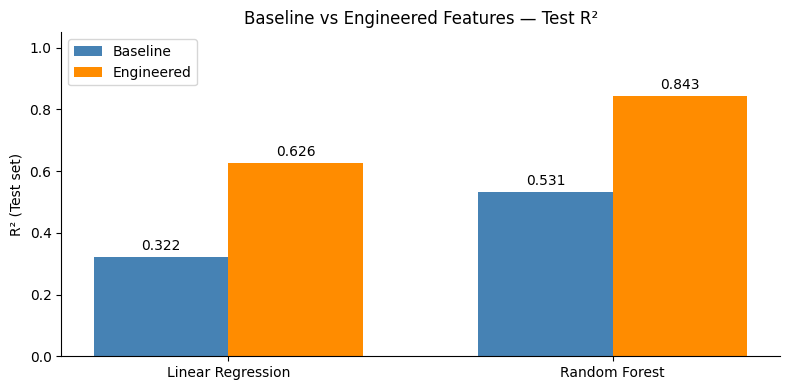

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(summary))
width = 0.35

bars1 = ax.bar(x - width/2, summary['R² Baseline'],  width, label='Baseline',   color='steelblue')
bars2 = ax.bar(x + width/2, summary['R² Engineered'], width, label='Engineered', color='darkorange')

ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

ax.set_xticks(x)
ax.set_xticklabels(summary['Model'])
ax.set_ylabel('R² (Test set)')
ax.set_title('Baseline vs Engineered Features — Test R²')
ax.set_ylim(0, 1.05)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

---
## 8 · Key Takeaways

| Observation | Detail |
|---|---|
| **`hour` is the most powerful feature** | Bike demand follows a clear morning/evening commute pattern. Exposing the hour as a categorical variable lets tree-based models capture this non-linearly. |
| **`month` & `day` add seasonal signal** | Demand peaks in summer and is lower on weekends. |
| **`temp_variance` adds context** | The difference between felt and actual temperature can influence ride comfort, complementing the raw temperature reading. |
| **Random Forest >> Linear Regression** | The relationships here are non-linear; a tree ensemble handles them far better. |
| **Potential next steps** | Try `GradientBoostingRegressor` / XGBoost; add interaction terms (e.g. `hour × weather`); tune `max_depth` & `n_estimators` with `GridSearchCV`. |